# Explicabilidad con SHAP — Heart Disease Dataset

Proyecto académico: detección temprana de enfermedades cardiovasculares con Machine Learning explicable.

> Aunque SVM obtuvo el mayor ROC-AUC en test, este notebook utiliza Regresión Logística para SHAP por su interpretabilidad, desempeño competitivo y alineación con IA Responsable en contexto clínico.

## 1. Instalación e importación de librerías

In [1]:
!pip -q install shap

import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATASET_PATH = "heart_disease_processed.csv"

## 2. Carga del dataset procesado

El dataset debe provenir del notebook de preprocesamiento. La columna `target` es la variable objetivo; `num` no debe estar presente para evitar *data leakage*.

In [2]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        "No se encontró heart_disease_processed.csv. "
        "Ejecuta primero el notebook 02_Preprocessing_Heart_Disease.ipynb "
        "o sube el archivo al entorno de Colab."
    )

df = pd.read_csv(DATASET_PATH)

if "num" in df.columns:
    raise ValueError("La columna `num` no debe estar presente porque introduce data leakage.")

X = df.drop(columns=["target"])
y = df["target"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("Variables predictoras:")
display(pd.DataFrame({"variable": X.columns}))
display(df.head())

Dimensiones de X: (303, 25)
Dimensiones de y: (303,)
Variables predictoras:


,variable
0,age
1,trestbps
2,chol
3,thalach
4,oldpeak
5,ca
6,sex_0
7,sex_1
8,cp_1
9,cp_2


,age,trestbps,chol,thalach,oldpeak,ca,sex_0,sex_1,cp_1,cp_2,cp_3,cp_4,fbs_0,fbs_1,restecg_0,restecg_1,restecg_2,exang_0,exang_1,slope_1,slope_2,slope_3,thal_3.0,thal_6.0,thal_7.0,target
0,0.948726,0.757525,-0.264900,0.017197,1.087338,-0.711131,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,1,0,0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,2.504881,0,1,0,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,0,1
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,1.432877,0,1,0,0,0,1,1,0,0,0,1,0,1,0,1,0,0,0,1,1
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,-0.711131,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-0.711131,1,0,0,1,0,0,1,0,0,0,1,1,0,1,0,0,1,0,0,0


## 3. Entrenamiento de Logistic Regression

Se utiliza la misma división estratificada que en los notebooks previos para preservar la proporción de pacientes con y sin enfermedad cardiovascular.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

logistic_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_proba = logistic_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

pd.DataFrame([metrics]).T.rename(columns={0: "valor"})

,valor
Accuracy,0.868852
Precision,0.812500
Recall,0.928571
F1-score,0.866667
ROC-AUC,0.957792


## 4. Aplicación de SHAP

Para Regresión Logística, SHAP permite descomponer la predicción en contribuciones por variable. Los valores positivos empujan la predicción hacia mayor riesgo y los negativos hacia menor riesgo.

In [5]:
explainer = shap.Explainer(logistic_model, X_train, feature_names=X_train.columns)
shap_values = explainer(X_test)

print("Forma de shap_values:", shap_values.values.shape)

Forma de shap_values: (61, 25)


## 5. Explicabilidad global

El gráfico resumen muestra importancia y dirección del efecto. En general:

- Valores SHAP positivos aumentan la probabilidad estimada de enfermedad cardiovascular.
- Valores SHAP negativos disminuyen la probabilidad estimada.
- El color representa el valor de la variable: rojo indica valores altos y azul valores bajos.

### SHAP Summary Plot

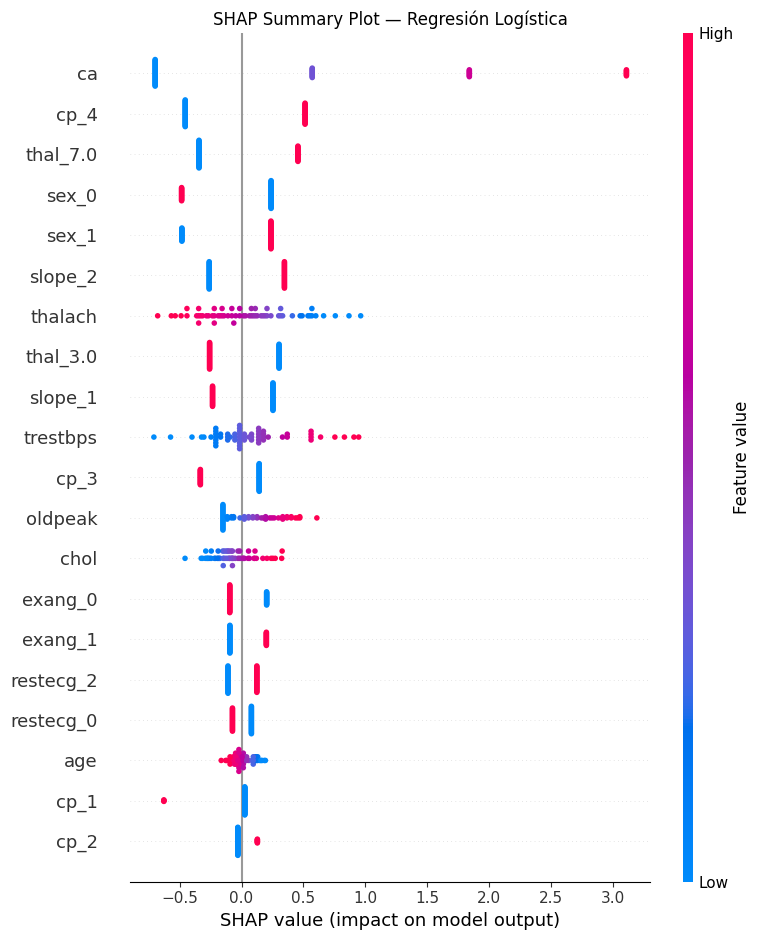

In [6]:
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot — Regresión Logística")
plt.tight_layout()
plt.savefig("summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### SHAP Bar Plot

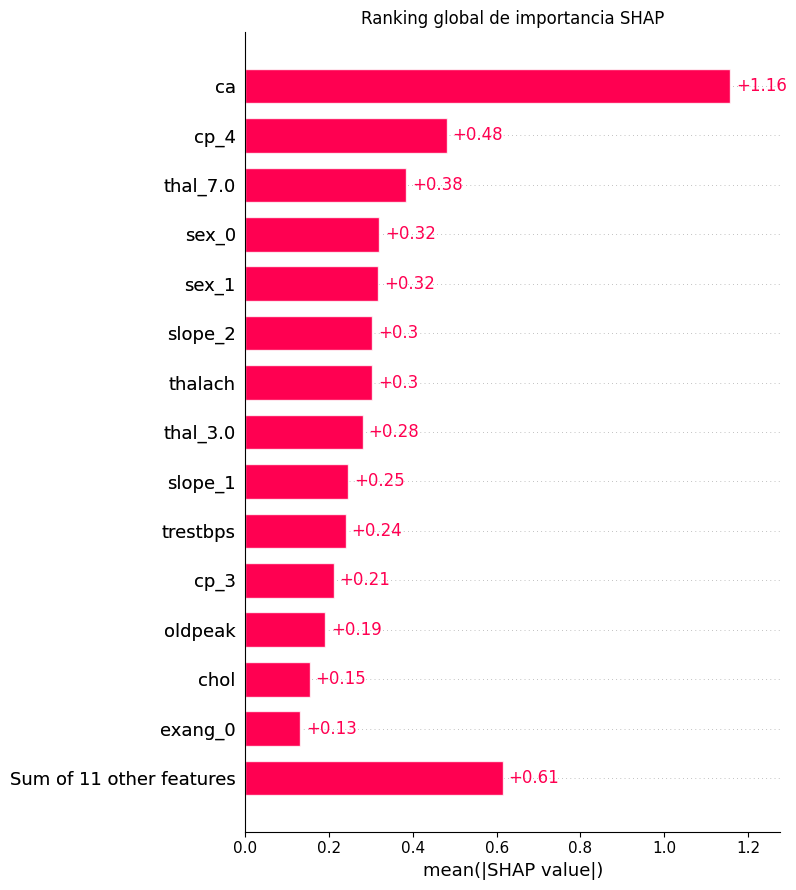

In [7]:
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Ranking global de importancia SHAP")
plt.tight_layout()
plt.savefig("bar_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
def interpretar_direccion_shap(shap_explanation, features_dataframe: pd.DataFrame, top_n: int = 8) -> pd.DataFrame:
    """Resume la dirección promedio de las contribuciones SHAP por variable.

    Parámetros
    ----------
    shap_explanation : shap.Explanation
        Valores SHAP calculados sobre el conjunto de prueba.
    features_dataframe : pd.DataFrame
        Datos usados para calcular SHAP.
    top_n : int
        Cantidad de variables más importantes a mostrar.

    Retorna
    -------
    pd.DataFrame
        Tabla con importancia media y dirección promedio del efecto.
    """
    mean_abs = np.abs(shap_explanation.values).mean(axis=0)
    mean_value = features_dataframe.mean(axis=0).values
    mean_shap = shap_explanation.values.mean(axis=0)

    direction = np.where(mean_shap > 0, "incrementa riesgo", "disminuye riesgo")

    return (
        pd.DataFrame({
            "Variable": features_dataframe.columns,
            "Importancia SHAP promedio": mean_abs,
            "Valor promedio estandarizado/codificado": mean_value,
            "Dirección promedio": direction,
        })
        .sort_values("Importancia SHAP promedio", ascending=False)
        .head(top_n)
    )


interpretar_direccion_shap(shap_values, X_test)

,Variable,Importancia SHAP promedio,Valor promedio estandarizado/codificado,Dirección promedio
5,ca,1.157959,0.237856,incrementa riesgo
11,cp_4,0.480788,0.442623,disminuye riesgo
24,thal_7.0,0.384113,0.360656,disminuye riesgo
6,sex_0,0.319143,0.327869,incrementa riesgo
7,sex_1,0.317645,0.672131,incrementa riesgo
20,slope_2,0.303248,0.491803,incrementa riesgo
3,thalach,0.302814,-0.061765,incrementa riesgo
22,thal_3.0,0.279515,0.524590,incrementa riesgo


## 6. Explicabilidad local

Se seleccionan tres pacientes del conjunto de prueba:

1. Paciente correctamente clasificado como sano.
2. Paciente correctamente clasificado con enfermedad.
3. Caso difícil, cercano al umbral de decisión 0.5.

In [9]:
def seleccionar_pacientes_representativos(y_true, y_pred, y_probability) -> dict[str, int]:
    """Selecciona pacientes representativos para explicabilidad local.

    Parámetros
    ----------
    y_true : pd.Series
        Etiquetas reales del conjunto de prueba.
    y_pred : np.ndarray
        Predicciones binarias del modelo.
    y_probability : np.ndarray
        Probabilidades estimadas para la clase positiva.

    Retorna
    -------
    dict[str, int]
        Índices posicionales para generar gráficos Waterfall.
    """
    healthy_candidates = np.where((y_true.values == 0) & (y_pred == 0))[0]
    disease_candidates = np.where((y_true.values == 1) & (y_pred == 1))[0]
    difficult_case = int(np.argmin(np.abs(y_probability - 0.5)))

    return {
        "paciente_sano_correcto": int(healthy_candidates[0]),
        "paciente_enfermo_correcto": int(disease_candidates[0]),
        "caso_dificil": difficult_case,
    }


selected_patients = seleccionar_pacientes_representativos(y_test, y_pred, y_proba)
selected_patients

{'paciente_sano_correcto': 0,
 'paciente_enfermo_correcto': 8,
 'caso_dificil': 32}

In [10]:
def resumir_paciente(patient_index: int) -> pd.DataFrame:
    """Resume predicción, etiqueta real y variables clínicas clave del paciente.

    Parámetros
    ----------
    patient_index : int
        Índice posicional del paciente en el conjunto de prueba.

    Retorna
    -------
    pd.DataFrame
        Resumen clínico y predictivo del caso seleccionado.
    """
    clinical_patterns = ["age", "chol", "exang", "thal", "ca"]
    clinical_columns = [
        column for column in X_test.columns
        if any(column == pattern or column.startswith(f"{pattern}_") for pattern in clinical_patterns)
    ]

    summary = X_test.loc[[patient_index], clinical_columns].copy()
    summary.insert(0, "probabilidad_enfermedad", y_proba[patient_index])
    summary.insert(0, "prediccion", y_pred[patient_index])
    summary.insert(0, "valor_real", y_test.iloc[patient_index])
    return summary


for label, patient_index in selected_patients.items():
    print(label, "-> índice", patient_index)
    display(resumir_paciente(patient_index))

paciente_sano_correcto -> índice 0


,valor_real,prediccion,probabilidad_enfermedad,age,chol,ca,exang_0,exang_1,thal_3.0,thal_6.0,thal_7.0
0,0,0,0.218567,0.505451,0.470232,-0.711131,1,0,1,0,0


paciente_enfermo_correcto -> índice 8


,valor_real,prediccion,probabilidad_enfermedad,age,chol,ca,exang_0,exang_1,thal_3.0,thal_6.0,thal_7.0
8,1,1,0.752856,-2.154202,0.683033,-0.711131,0,1,0,0,1


caso_dificil -> índice 32


,valor_real,prediccion,probabilidad_enfermedad,age,chol,ca,exang_0,exang_1,thal_3.0,thal_6.0,thal_7.0
32,1,1,0.526996,-1.156832,-1.503017,-0.711131,0,1,0,1,0


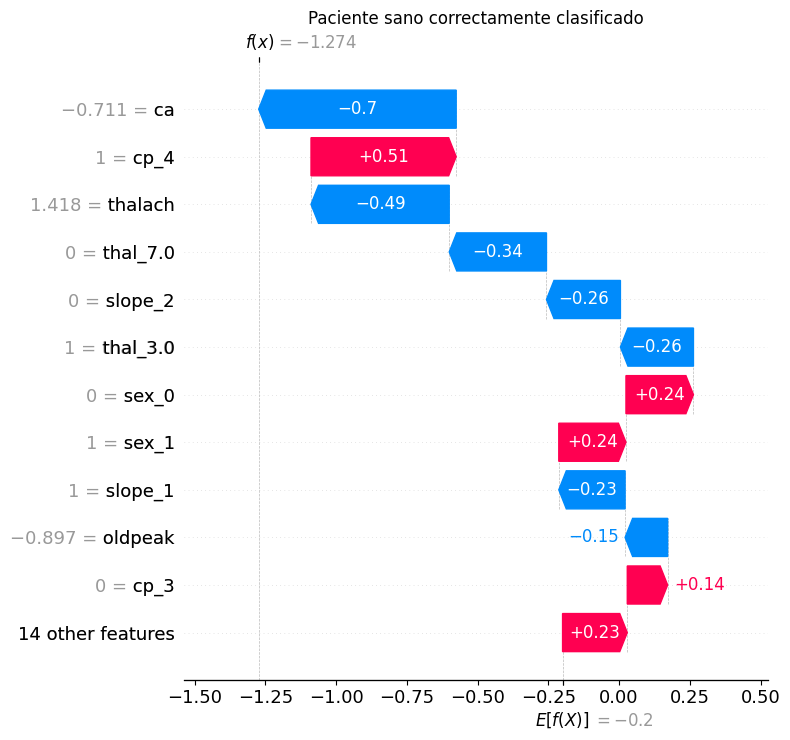

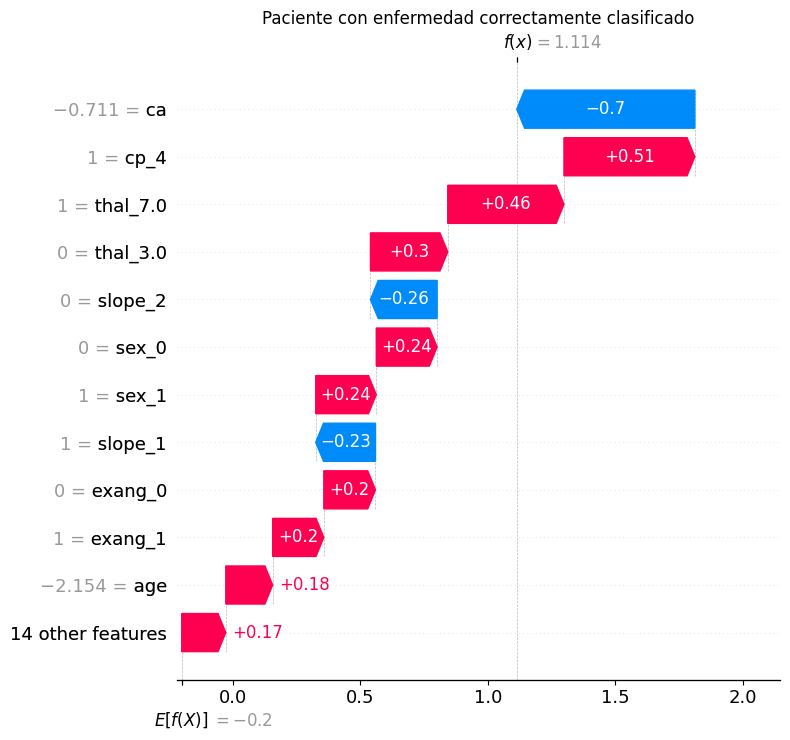

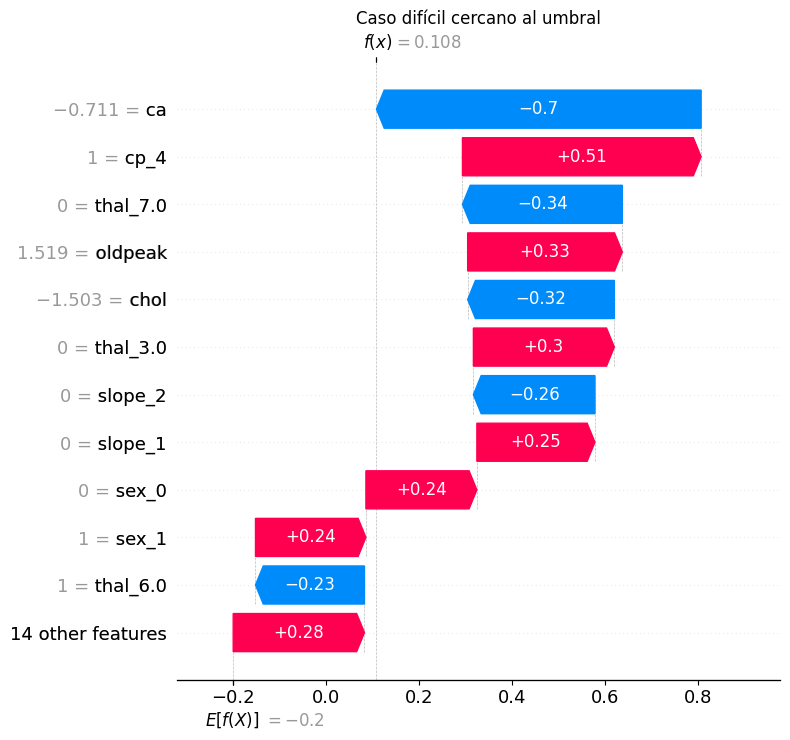

In [11]:
def guardar_waterfall(patient_index: int, filename: str, title: str) -> None:
    """Genera y guarda un Waterfall Plot para un paciente.

    Parámetros
    ----------
    patient_index : int
        Índice posicional del paciente en el conjunto de prueba.
    filename : str
        Nombre del archivo PNG de salida.
    title : str
        Título clínico del gráfico.

    Retorna
    -------
    None
        Guarda la figura y la muestra en pantalla.
    """
    shap.plots.waterfall(shap_values[patient_index], max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


waterfall_files = [
    (selected_patients["paciente_sano_correcto"], "waterfall_patient_1.png", "Paciente sano correctamente clasificado"),
    (selected_patients["paciente_enfermo_correcto"], "waterfall_patient_2.png", "Paciente con enfermedad correctamente clasificado"),
    (selected_patients["caso_dificil"], "waterfall_patient_3.png", "Caso difícil cercano al umbral"),
]

for patient_index, filename, title in waterfall_files:
    guardar_waterfall(patient_index, filename, title)

### Interpretación clínica local

En cada Waterfall Plot, las variables que empujan la predicción hacia la derecha aumentan el riesgo estimado, mientras que las variables hacia la izquierda disminuyen el riesgo. Para la discusión clínica conviene revisar especialmente edad (`age`), colesterol (`chol`), angina inducida por ejercicio (`exang`), talasemia (`thal`) y número de vasos coloreados por fluoroscopia (`ca`).

## 7. Identificación de factores de riesgo

In [12]:
def obtener_variable_base(feature_name: str) -> str:
    """Agrupa variables one-hot bajo su variable clínica original.

    Parámetros
    ----------
    feature_name : str
        Nombre de una columna procesada.

    Retorna
    -------
    str
        Variable clínica base.
    """
    for base_variable in ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]:
        if feature_name.startswith(f"{base_variable}_"):
            return base_variable
    return feature_name


shap_feature_importance = pd.DataFrame({
    "Variable": X_test.columns,
    "Variable base": [obtener_variable_base(column) for column in X_test.columns],
    "Importancia SHAP promedio": np.abs(shap_values.values).mean(axis=0),
})

shap_feature_importance = (
    shap_feature_importance
    .groupby("Variable base", as_index=False)["Importancia SHAP promedio"]
    .sum()
    .rename(columns={"Variable base": "Variable"})
    .sort_values("Importancia SHAP promedio", ascending=False)
    .reset_index(drop=True)
)

shap_feature_importance

,Variable,Importancia SHAP promedio
0,ca,1.157959
1,cp,0.800443
2,thal,0.696932
3,sex,0.636787
4,slope,0.564055
5,thalach,0.302814
6,exang,0.259689
7,trestbps,0.239358
8,restecg,0.198123
9,oldpeak,0.190769


In [14]:
medical_literature_variables = {"thal", "ca", "exang", "age", "chol"}
top_shap_variables = set(shap_feature_importance.head(5)["Variable"])
matching_variables = sorted(top_shap_variables.intersection(medical_literature_variables))

print("Variables top SHAP que coinciden con literatura médica:", matching_variables)

Variables top SHAP que coinciden con literatura médica: ['ca', 'thal']


## 8. Conclusiones automáticas

In [15]:
def generar_conclusiones_shap(feature_importance: pd.DataFrame, matched_variables: list[str]) -> list[str]:
    """Genera conclusiones automáticas del análisis SHAP.

    Parámetros
    ----------
    feature_importance : pd.DataFrame
        Tabla de importancia SHAP promedio por variable clínica.
    matched_variables : list[str]
        Variables importantes que coinciden con factores reportados en literatura médica.

    Retorna
    -------
    list[str]
        Conclusiones interpretables para el artículo científico.
    """
    top_variables = feature_importance.head(5)["Variable"].tolist()
    matched_text = ", ".join(matched_variables) if matched_variables else "ninguna variable principal"

    return [
        f"Las variables más influyentes según SHAP fueron: {', '.join(top_variables)}.",
        f"Las variables coincidentes con conocimiento médico previo fueron: {matched_text}.",
        "El modelo aporta utilidad clínica porque permite estimar riesgo y explicar qué factores empujan cada predicción.",
        "La IA explicable mejora la transparencia, facilita auditoría clínica y reduce el uso de modelos tipo caja negra en salud.",
        "Regresión Logística es una elección metodológicamente adecuada porque combina interpretabilidad, estabilidad y desempeño competitivo frente a modelos más complejos.",
    ]


for index, conclusion in enumerate(generar_conclusiones_shap(shap_feature_importance, matching_variables), start=1):
    print(f"{index}. {conclusion}")

1. Las variables más influyentes según SHAP fueron: ca, cp, thal, sex, slope.
2. Las variables coincidentes con conocimiento médico previo fueron: ca, thal.
3. El modelo aporta utilidad clínica porque permite estimar riesgo y explicar qué factores empujan cada predicción.
4. La IA explicable mejora la transparencia, facilita auditoría clínica y reduce el uso de modelos tipo caja negra en salud.
5. Regresión Logística es una elección metodológicamente adecuada porque combina interpretabilidad, estabilidad y desempeño competitivo frente a modelos más complejos.


## 9. Exportación opcional

In [ ]:
shap_feature_importance.to_csv("shap_feature_importance.csv", index=False)
joblib.dump(logistic_model, "logistic_regression_shap_model.pkl")

print("Archivos guardados:")
print("- shap_feature_importance.csv")
print("- logistic_regression_shap_model.pkl")
print("- summary_plot.png")
print("- bar_plot.png")
print("- waterfall_patient_1.png")
print("- waterfall_patient_2.png")
print("- waterfall_patient_3.png")

## 10. Redacción científica automática para la sección Discusión

In [16]:
def generar_discusion_cientifica(feature_importance: pd.DataFrame, matched_variables: list[str]) -> str:
    """Genera un texto académico breve para discutir los resultados SHAP.

    Parámetros
    ----------
    feature_importance : pd.DataFrame
        Ranking de importancia SHAP promedio por variable clínica.
    matched_variables : list[str]
        Variables relevantes que coinciden con conocimiento médico previo.

    Retorna
    -------
    str
        Párrafo académico para la sección Discusión del artículo.
    """
    top_three = feature_importance.head(3)["Variable"].tolist()
    matched_text = ", ".join(matched_variables) if matched_variables else "un subconjunto limitado de variables clínicas esperadas"

    return (
        "El análisis de explicabilidad basado en SHAP permitió identificar los factores que más contribuyeron "
        "a la predicción de enfermedad cardiovascular en el modelo de Regresión Logística. Las variables con "
        f"mayor contribución promedio fueron {', '.join(top_three)}, lo que sugiere que el modelo captura señales "
        "clínicamente relevantes para la estratificación temprana del riesgo. La coincidencia de variables como "
        f"{matched_text} con factores reconocidos en la literatura médica fortalece la plausibilidad clínica del "
        "modelo. Desde la perspectiva de IA Responsable, la elección de Regresión Logística favorece la transparencia "
        "y facilita que profesionales de la salud auditen las predicciones, especialmente en escenarios donde no basta "
        "con maximizar el desempeño predictivo, sino que también se requiere justificar las decisiones algorítmicas. "
        "Por tanto, SHAP complementa el modelo al ofrecer explicaciones globales y locales que pueden apoyar la "
        "discusión clínica, la comunicación de riesgo y futuras estrategias de validación externa."
    )


discussion_text = generar_discusion_cientifica(shap_feature_importance, matching_variables)
print(discussion_text)

El análisis de explicabilidad basado en SHAP permitió identificar los factores que más contribuyeron a la predicción de enfermedad cardiovascular en el modelo de Regresión Logística. Las variables con mayor contribución promedio fueron ca, cp, thal, lo que sugiere que el modelo captura señales clínicamente relevantes para la estratificación temprana del riesgo. La coincidencia de variables como ca, thal con factores reconocidos en la literatura médica fortalece la plausibilidad clínica del modelo. Desde la perspectiva de IA Responsable, la elección de Regresión Logística favorece la transparencia y facilita que profesionales de la salud auditen las predicciones, especialmente en escenarios donde no basta con maximizar el desempeño predictivo, sino que también se requiere justificar las decisiones algorítmicas. Por tanto, SHAP complementa el modelo al ofrecer explicaciones globales y locales que pueden apoyar la discusión clínica, la comunicación de riesgo y futuras estrategias de valid